# Image Processing in Quantum Computers — FRQI Implementation

This notebook implements the **Flexible Representation of Quantum Images (FRQI)** encoding scheme described in Le, Dong & Hirota (2011), following the walkthrough in *"Image Processing in Quantum Computers"* (Dendukuri & Luu, 2018, [arXiv:1812.11042](https://arxiv.org/abs/1812.11042)).

A companion write-up with the full explanation, derivations, and discussion of some inconsistencies found in the original paper is available on [Medium Blog](https://medium.com/@arpitha.rajeev37/image-processing-in-quantum-computers-a76ee63f5041?sharedUserId=arpitha.rajeev37).

**What this notebook does:**
1. **Phase 1 — Encoding:** Convert a classical 2×2 grayscale image into an FRQI quantum state using Hadamard + multi-controlled `RY` gates.
2. **Phase 2 — Measurement & Retrieval:** Simulate the circuit, measure it, and reconstruct pixel intensities from the measurement statistics.
3. **Phase 3 — Negation:** Apply a spatial-domain image processing operation (intensity inversion) directly at the quantum circuit level, and verify the recovered result.


## Setup

Import Qiskit, Aer, and plotting libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import RYGate
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager

## Phase 1: Representing Image Pixels as a Quantum Image

We use a tiny 2×2 grayscale image as our running example:

| | Col 0 | Col 1 |
|---|---|---|
| **Row 0** | 255 (White) | 0 (Black) |
| **Row 1** | 128 (Mid-Gray) | 64 (Dark Gray) |

A 2×2 image needs **2 position qubits** (to index all 4 coordinates) plus **1 color qubit** (to hold the intensity as a rotation angle), for 3 qubits total.

In [2]:
# 1. Define classical 2x2 grayscale image matrix
# Coordinates: (row, col) -> (0,0)=Top-Left, (0,1)=Top-Right, etc.
pixel_00 = 255  # White
pixel_01 = 0    # Black
pixel_10 = 128  # Mid-Gray
pixel_11 = 64   # Dark Gray

In [3]:
original_pixels = {'00': pixel_00, '01': pixel_01, '10': pixel_10, '11': pixel_11}

### FRQI angle conversion

Each classical pixel value is mapped to a rotation angle θ using:

$$\theta = \frac{\text{pixel\_value}}{255} \times \frac{\pi}{2}$$

Qiskit's `RY(φ)` gate implements `cos(φ/2)|0⟩ + sin(φ/2)|1⟩`, so we pass in `φ = 2θ` to get the standard FRQI state `cos(θ)|0⟩ + sin(θ)|1⟩` on the color qubit.

In [4]:
# =====================================================================
# PHASE 1: Representing Image Pixels as a Quantum Image
# =====================================================================
# 2. FRQI Angle Conversion Function: theta = (C / 255) * (pi / 2)
# Note: Qiskit's RY gate rotates by 2*theta internally, so we pre-multiply by 2.
def pixel_to_angle(pixel_value):
    angle = (pixel_value / 255.0) * (np.pi/2)
    return 2*angle

angles = {
    '00': pixel_to_angle(pixel_00),
    '01': pixel_to_angle(pixel_01),
    '10': pixel_to_angle(pixel_10),
    '11': pixel_to_angle(pixel_11)
}

### Building the encoding circuit

For each of the 4 coordinate states, we temporarily flip the position qubits with `X` gates so that the target coordinate maps onto the `|11⟩` control pattern, apply a multi-controlled `RY(2θ)` gate onto the color qubit, then flip the position qubits back (uncompute). This entangles the color qubit's rotation with one specific position state at a time, without disturbing the others.

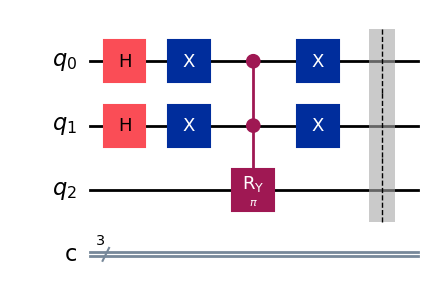

In [5]:
# 3. Initialize Quantum Circuit
# 2 position qubits (0, 1) + 1 color qubit (2)
qc = QuantumCircuit(3,3)
qc.h([0,1])
# --- Encode Pixel (0,0) ---
# Target coordinate state |00>: Flip both qubits to '1' to activate controls
qc.x(0)
qc.x(1)
controlled_ry_00 = RYGate(angles['00']).control(num_ctrl_qubits=2)
qc.append(controlled_ry_00, [0, 1, 2])
qc.x(0) # Uncompute: Flip back to normal
qc.x(1) # Uncompute: Flip back to normal
qc.barrier()
qc.draw(output="mpl")

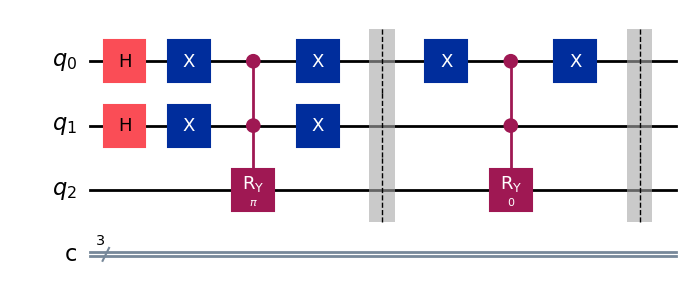

In [6]:
# --- Encode Pixel (0,1) ---
# Target coordinate state |01>: Flip qubit 0 to '1'
qc.x(0)
controlled_ry_01 = RYGate(angles['01']).control(num_ctrl_qubits=2)
qc.append(controlled_ry_01, [0, 1, 2])
qc.x(0)  # Uncompute
qc.barrier()
qc.draw(output="mpl")

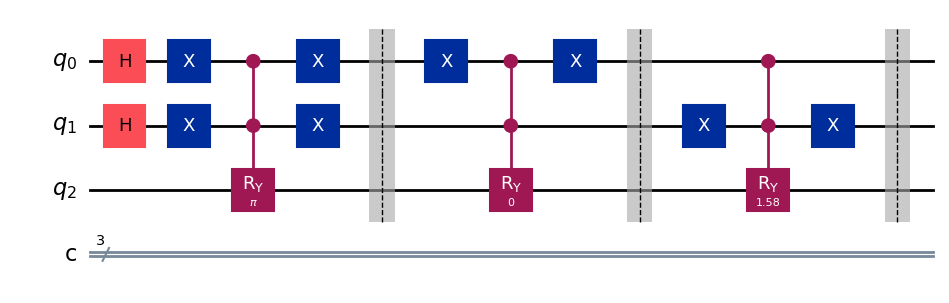

In [7]:
# --- Encode Pixel (1,0) ---
# Target coordinate state |10>: Flip qubit 1 to '1'
qc.x(1)
controlled_ry_10 = RYGate(angles['10']).control(num_ctrl_qubits=2)
qc.append(controlled_ry_10, [0, 1, 2])
qc.x(1)  # Uncompute
qc.barrier()
qc.draw(output="mpl")

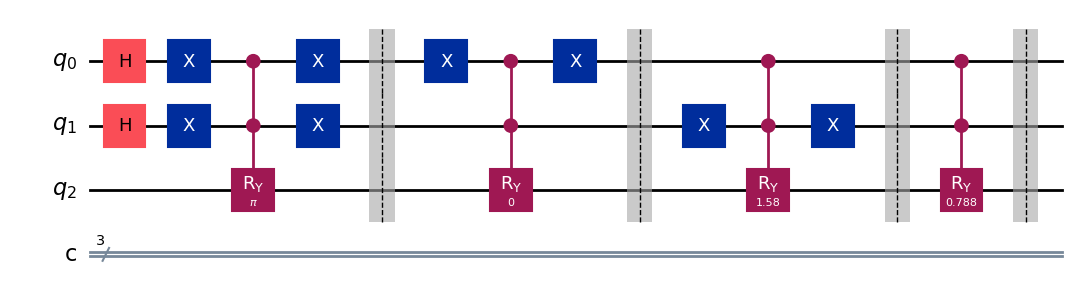

In [8]:
# --- Encode Pixel (1,1) ---
# Target coordinate state |11>: Controls are already naturally '1'
controlled_ry_11 = RYGate(angles['11']).control(num_ctrl_qubits=2)
qc.append(controlled_ry_11, [0, 1, 2])
qc.barrier()
qc.draw(output="mpl")

## Phase 2: Measurement and Retrieval

We can't read amplitudes directly off a quantum computer — we can only measure and collect statistics. For each position, the probability of measuring the color qubit as `|1⟩` is `sin²(θ)`, so we invert that relationship to recover an estimate of θ (and therefore the original pixel value) from the measured counts:

$$\hat\theta = \arcsin\left(\sqrt{P(1 \mid \text{position})}\right) \quad\rightarrow\quad \text{pixel} = \frac{\hat\theta}{\pi/2}\times 255$$

**Note on bit ordering:** Qiskit's measurement bitstrings are read `c2 c1 c0` (most-significant classical bit first). Since our encoding circuit above addresses coordinates using a `(q0)(q1)` convention (e.g. flipping only `q0` targets coordinate `01`), the decode step below reassembles the position key as `bitstring[2] + bitstring[1]` — i.e. `(q0)(q1)` order — to match. Getting this order wrong silently swaps pixel values between non-symmetric coordinates (`01` ↔ `10`) while `00`/`11` still look correct, which makes it an easy bug to miss.

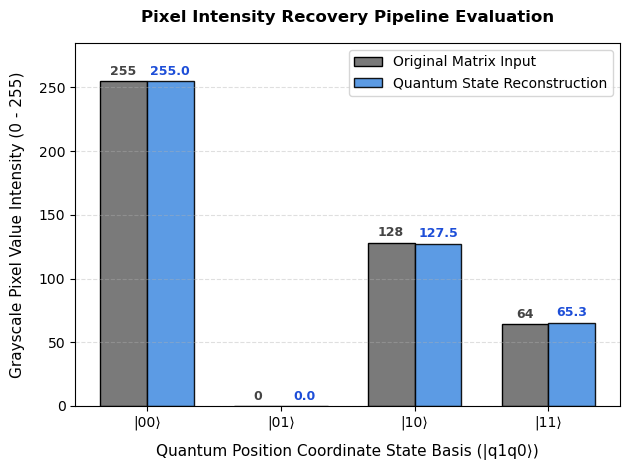

In [9]:
# =====================================================================
# PHASE 2: MEASUREMENT, SIMULATION, DECODING & VISUALIZATION
# =====================================================================
def run_decode_and_plot(qc):
    # Target simulator setup
    simulator = AerSimulator()
    shots = 10000
    
    # Map Quantum bits directly to Classical bits for tracking
    qc.measure([0, 1, 2], [0, 1, 2])
    
    # Compile/Transpile custom multi-controlled gates down to native simulator hardware gates
    pm = generate_preset_pass_manager(3, simulator)
    transpiled_qc = pm.run(qc)
    
    # Run the experiment
    result = simulator.run(transpiled_qc, shots=shots).result()
    counts = result.get_counts()
    
    # Initialize trackers for probability tracking
    position_totals = {'00': 0, '01': 0, '10': 0, '11': 0}
    color_one_counts = {'00': 0, '01': 0, '10': 0, '11': 0}

    # Process individual hardware string outputs
    for bitstring, count in counts.items():
        # Qiskit registers map right-to-left to string indices:
        # bitstring[0] = c_reg 2 (Qubit 2 / Color)
        # bitstring[1] = c_reg 1 (Qubit 1 / Position 1)
        # bitstring[2] = c_reg 0 (Qubit 0 / Position 0)
        color_bit = bitstring[0]
        pos_key = bitstring[2] + bitstring[1]  # Yields 'q1q0' layout string matching classical keys
        
        position_totals[pos_key] += count
        if color_bit == '1':
            color_one_counts[pos_key] += count

    # Statistical reconstruction math
    recovered_intensities = {}
    for pos, total_shots_at_pos in position_totals.items():
        if total_shots_at_pos > 0:
            p1 = color_one_counts[pos] / total_shots_at_pos
            p1 = min(1.0, max(0.0, p1))  
            
            # FRQI Core Extraction: theta = arcsin(sqrt(P(1|position)))
            theta_est = np.arcsin(np.sqrt(p1))
            # Rescale the extracted phase angle back into a 0-255 classical grayscale intensity value
            recovered_intensities[pos] = (theta_est / (np.pi / 2)) * 255
        else:
            recovered_intensities[pos] = 0

    positions = sorted(list(recovered_intensities.keys()))
    original_vals = [original_pixels[p] for p in positions]
    recovered_vals = [recovered_intensities[p] for p in positions]
    
    x = np.arange(len(positions))
    width = 0.35
    
    plt.bar(x - width/2, original_vals, width, label='Original Matrix Input', color='#7A7A7A', edgecolor='black')
    plt.bar(x + width/2, recovered_vals, width, label='Quantum State Reconstruction', color='#4A90E2', edgecolor='black', alpha=0.9)
    
    plt.title('Pixel Intensity Recovery Pipeline Evaluation', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Quantum Position Coordinate State Basis (|q1q0⟩)', fontsize=11, labelpad=10)
    plt.ylabel('Grayscale Pixel Value Intensity (0 - 255)', fontsize=11, labelpad=10)
    plt.xticks(x, [f'|{p}⟩' for p in positions])
    plt.ylim(0, 285)
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Annotate values directly onto the bars
    for i, (orig, rec) in enumerate(zip(original_vals, recovered_vals)):
        plt.text(i - width/2, orig + 5, str(orig), ha='center', fontsize=9, fontweight='bold', color='#444444')
        plt.text(i + width/2, rec + 5, str(round(rec, 1)), ha='center', fontsize=9, fontweight='bold', color='#1D4ED8')

    plt.tight_layout()
    plt.show()
    plt.close()

run_decode_and_plot(qc)

## Phase 3: Image Processing — Negation

To show that we can manipulate the encoded data (not just retrieve it), we apply an **inversion** (negation) operation. Rather than adding an extra rotation on top of the existing circuit, we rebuild the encoding from scratch using negated angles:

$$\theta_{\text{neg}} = \frac{\pi}{2} - \theta$$

which corresponds exactly to the classical negation `255 - pixel_value`, since `sin(π/2 - θ) = cos(θ)` swaps which color-qubit outcome is more probable.

In [10]:
# =====================================================================
# PHASE 3: NEGATED RUN, DECODE & PLOT PIPELINE
# =====================================================================
def run_decode_and_plot_negated(qc):
    # Target simulator setup
    simulator = AerSimulator()
    shots = 10000
    
    # Map Quantum bits directly to Classical bits for tracking
    qc.measure([0, 1, 2], [0, 1, 2])
    
    # Compile/Transpile custom multi-controlled gates down to native simulator hardware gates
    pm = generate_preset_pass_manager(3, simulator)
    transpiled_qc = pm.run(qc)
    
    # Run the experiment
    result = simulator.run(transpiled_qc, shots=shots).result()
    counts = result.get_counts()
    
    # Initialize trackers for probability tracking
    position_totals = {'00': 0, '01': 0, '10': 0, '11': 0}
    color_one_counts = {'00': 0, '01': 0, '10': 0, '11': 0}

    # Process individual hardware string outputs (your exact parsing logic)
    for bitstring, count in counts.items():
        color_bit = bitstring[0]
        pos_key = bitstring[2] + bitstring[1]  # Yields 'q1q0' layout string matching classical keys
        
        position_totals[pos_key] += count
        if color_bit == '1':
            color_one_counts[pos_key] += count

    # Statistical reconstruction math
    recovered_intensities = {}
    for pos, total_shots_at_pos in position_totals.items():
        if total_shots_at_pos > 0:
            p1 = color_one_counts[pos] / total_shots_at_pos
            p1 = min(1.0, max(0.0, p1))  
            
            # FRQI Core Extraction: theta = arcsin(sqrt(P(1|position)))
            theta_est = np.arcsin(np.sqrt(p1))
            # Rescale the extracted phase angle back into a 0-255 classical grayscale intensity value
            recovered_intensities[pos] = (theta_est / (np.pi / 2)) * 255
        else:
            recovered_intensities[pos] = 0

    # Build positions tracking matching classical layout keys
    positions = sorted(list(recovered_intensities.keys()))
    original_vals = [original_pixels[p] for p in positions]
    negated_vals = [recovered_intensities[p] for p in positions]
    
    x = np.arange(len(positions))
    width = 0.35
    
    # Plotting code using your custom styling, matched colors, and the accurate legend label
    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, original_vals, width, label='Original Input Matrix', color='#7A7A7A', edgecolor='black')
    plt.bar(x + width/2, negated_vals, width, label='Recovered Negated FRQI', color='#E54B4B', edgecolor='black', alpha=0.9)
    
    plt.title('Quantum Image State Evaluation: Standard Matrix vs Inversion', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Quantum Coordinate State Basis (|q1q0⟩)', fontsize=11, labelpad=10)
    plt.ylabel('Grayscale Spatial Intensity (0 - 255)', fontsize=11, labelpad=10)
    plt.xticks(x, [f'|{p}⟩' for p in positions])
    plt.ylim(0, 285)
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Annotate values directly onto the bars
    for i, (orig, neg) in enumerate(zip(original_vals, negated_vals)):
        plt.text(i - width/2, orig + 5, str(orig), ha='center', fontsize=9, fontweight='bold', color='#444444')
        plt.text(i + width/2, neg + 5, str(round(neg, 1)), ha='center', fontsize=9, fontweight='bold', color='#B91C1C')

    plt.tight_layout()
    plt.show()
    plt.close()

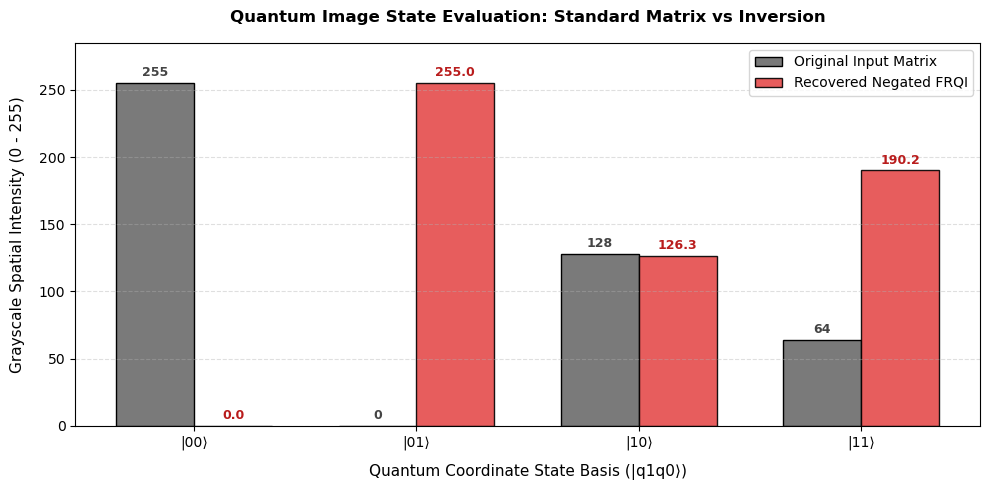

In [11]:
# =====================================================================
# PHASE 3: Negated circuit
# =====================================================================
def pixel_to_angle_negated(pixel_value):
    theta = (pixel_value / 255.0) * (np.pi / 2)
    theta_neg = (np.pi / 2) - theta
    return 2 * theta_neg

angles_neg = {k: pixel_to_angle_negated(v) for k, v in original_pixels.items()}

def build_frqi_circuit_negated():
    qc = QuantumCircuit(3, 3)
    qc.h([0, 1])

    qc.x([0, 1])
    qc.append(RYGate(angles_neg['00']).control(2), [0, 1, 2])
    qc.x([0, 1])
    qc.barrier()

    qc.x(0)
    qc.append(RYGate(angles_neg['01']).control(2), [0, 1, 2])
    qc.x(0)
    qc.barrier()

    qc.x(1)
    qc.append(RYGate(angles_neg['10']).control(2), [0, 1, 2])
    qc.x(1)
    qc.barrier()

    qc.append(RYGate(angles_neg['11']).control(2), [0, 1, 2])
    qc.barrier()

    return qc

qc_frqi_neg = build_frqi_circuit_negated()
negated_recovered = run_decode_and_plot_negated(qc_frqi_neg)

## Results Summary

- **Phase 2 (baseline):** recovered pixel intensities should closely match the original `[255, 0, 128, 64]` matrix, up to shot noise from the 10,000-shot simulation.
- **Phase 3 (negation):** recovered intensities should closely match `255 - original`, i.e. `[0, 255, 127, 191]`.

## What's Next: Stepping into the Fourier Basis

Now that we have a working FRQI state preparation pipeline and verified spatial manipulation via inversion, a natural next step is to bridge the gap between simple pixel-flipping and true quantum speedups. By appending a Quantum Fourier Transform (QFT) block directly to the position qubits of this circuit, you can shift the entire image grid from the computational basis into the Fourier basis and start manipulating images in the frequency domain.
